# Task 4: Generic aperture photometry_Script author: g.savini@ucl.ac.uk_ <br>
_Updated: 06/02/2026_ k

Task completed by: Klara Kurucova | 05/02/2026 | PHAS0020

<div class="alert alert-block alert-info">

**This session includes a few topics but will mainly review a concept you have already been introduced in PHAS0003: Aperture Photometry. Last year you used DS9 to easily go over stars and perform aperture photometry, here we will do the same thing but with a little more "control".**

By the end of this session, you will have learned about:
<ul>
<li> Further selection of data subsets;
<li> association of coordinates to images;
<li> creation of masks;
<li> Perform ab initio aperture photometry;
<li> The structure and radial profile of spiral galaxies.
</ul>
</div>
<div class="alert alert-success"> 

### Part 1 The image. ###
<p>
[1] Write a short Abstract where you describe what you did. This time however, do the following for habit. Write a short paragraph on what you think you will be doing after reading the guidelines in this green box. Don't worry about too much detail, but make sure it summarises what this task is about. 
If you manage to finish the task in time, come back to the Abstract at the end and you'll find you might want to rewrite it, or at any rate, add your findings and lessons learned.

I've started the first "import" cell with all the libraries you might need and a few more to introduce other useful tools.

Now choose one of the three images of the spiral galaxy on moodle. This image will be a specific filter image taken by the Hubble Space Telescope of NGC 7742. The scope will be to attempt to go through the various steps of performing aperture photometry similarly to a star but in a gradual way in order to obtain the Sersic profile of the galaxy, which represents the change in intensity as a function of the galaxy radius starting from its centre.

So first of all<br>
[1.2] Load the fits file into a variable (making sure you load the write field of the fits file).
I have added an example in the comment... but you can choose to replace this with one of the other images.<br>
[1.3] Then create a concise function that visualizes (using "imshow") the galaxy image using a dynamic range that emphasize the extent of the spiral's arms. [Hint if you simply visualize the galaxy it should look like a small dot at the center of the image]<br>

Now let's start to investigate the image before performing the photometry:
### Part 2 Subsets and Masks. ###

[2.1] Identify the center of the galaxy and use pixel coordinates assigned to a variable (or two) for ease of manipulation.
[2.2] To calculate the "background" that we would want to subtract from our photometry, we can't do a simple ring like that done around a star, so let's consider using the histogram of the image (as done before) to identify the highest value as that representing "empty space" or rather the median level of the sky background by considering the "mode" of the image. Once identified, subtract this value from the image as an offset.
[2.3] Now I have placed two cells below where I Illustrate a way to create arrays that represents the values of x, y for each pixel of any image of the same array size. It is up to you now to create a similar sized array where each pixel has the value of the distance from a certain point of your choice by combining the previously defined x and y matrices (it doesn't have to be any point in particular providing you have declared it).<br>
[2.4] To make sure we have mastered this aspect, declare any recognizable mathematical function of your choice and visualize it as an image by using the x and y array values.<p>

[2.5] Now define the x and y arrays that correspond to the size of the galaxy image. You can now create a photometric mask by defining a cylindrical function which is equal to 1 if the distance from the center of the galaxy is less than a distance of your choice and 0 outside. Show this in an image.

### Part 3 Aperture photometry ###
Now we can begin to perform the aperture photometry of the galaxy and to do so:<p>
[3.1] Create a for loop with an index kr that varies from 5 to 200. Initialize two linear arrays before the loop so that for each kr you can store the radius value (kr) and the flux value obtained by summing over all the pixel within a circle of that radius.<br>
For each radius, having already subtracted our background, we are in principle performing variable aperture photometry of the galaxy inner region as we expand the radius. In doing that you will measure an increasing amount of flux, but unlike stellar flux where we are only interested about the total sum, for the Sersic profile we are interested in the profile variation so we need to measure the change (or derivative with respect to the radius) of this set of integrations. <br>
[3.2] To do so you can take the 1-point derivative of the photometry stored values each time also dividing by the number of pixels in that ring (which can be done easily if in the loop you also store the sum of the pixels in each circle as the radius increases).<br>
[3.3] At this point, create a function that calculates the Sersic profile and plot it in a tidy plot with all the relevant elements (titles, units, legend etc)<br>
[3.4] After testing different visualizations of the Sersic plot, in a markdown cell, comment about the differences you observe in the different parts of the profil, especially in the three regions separated by the two values of radius $\sim 30$ and  $\sim 100$.

### Part 4 The Sersic profile ###

The mathematical expression of the __[Sersic profile](https://en.wikipedia.org/wiki/S%C3%A9rsic_profile)__  is a function of radius   

$$ I(R)= I_e e^{-b_n[(\frac{R}{Re})^{\frac{1}{n}}-1]}$$

Where,
- I_e is the intensity at Re 
- Re is half-light radius (pixels)
- $b_n \approx 2n-1/3$, for $n>8$ (and a more convoluted expression can be found in the wiki link above)
- n is Sérsic index (int) that controls the degree of curvature of the profile

Now
[4.1] Create a function that fits, using "optimize.curve.fit" as we have done before, the Sersic profile function to different parts of the obtained profile.
[4.2] Knowing that "n" values between 1 and 10 can be expected with spiral galaxies somewhere in the 2 to 3 range, comment on the different values obtained for the different regions and how these relate to different galaxy types.

</div>

In [1]:
# Pre-filled Cell 
# Here is our usual importing cell. In this task this is done for you as there are a few extra things to import#
import os
import numpy as np
import matplotlib.pyplot as plt
import statistics as stats
from scipy import optimize 
from scipy import ndimage

#Astropy can come in handy as it has quite a lot of libraries that aid with coordinate conversion and other tools.
from astropy.io import fits
#from astropy.wcs import WCS
#from astropy.coordinates import SkyCoord
#from astropy.nddata import Cutout2D
#import astropy.units as u
#from astropy.coordinates import Angle

# The following line makes the images a bit larger than default - works better on a large screen. Use it if you want to make a larger figure.
plt.rcParams['figure.figsize'] = 15,12

## Part 1


### 1.1 Abstract

In this task we will work with a FITS image of galaxy NGC7742 taken by the Hubble Space Telescope. We will apply masks to regions of the galaxy at differenet radii and compute flux in circular regions of the mask. We will look at the variations of intensity in different masked areas with the ultimate goal of fitting a Sersic profile to our data to model the behaviour of intensity in different regions of the galaxy.

### 1.2: Loading the FITS image

First let us load the FITS image we will be working with in this task.

In [8]:
###########  Loading the Images #############################################
home_dir = os.getcwd()+'/'
print ("The Home Directory is set to:", home_dir) 
NGC7742_675= fits.open(f"{home_dir}F675W_u2pq0405t_c0m.fits")[3]
NGC7742_675_image = NGC7742_675.data


The Home Directory is set to: /Users/klarakurucova/Desktop/UCL /Practical astrophysics and computing /week 4/


### 1.3: Function for image visualisation

We now create a function that will visualize the galaxy. It is important that we run some stats on the image first and adjust the floor and ceiling of the image as we expect the galaxy to be faint and we want to bring emphasis to the spiral arms. 

In [12]:
###STUDENT GENERATED CELLS###

#function that displays the FITS image

def show_image (image_data):
    """This function visualises a FITS image with an appropriate floor and ceiling values
    Input:
    image_data = a FITS image converted to data
    
    Output:
    Matplotlib visualisation of the image"""
    
    #run some stats
    mean_galaxy = np.mean(image_data)
    std_galaxy = np.std(image_data)
    vmin_galaxy = mean_galaxy - 0.5 * std_galaxy
    vmax_galaxy = mean_galaxy + 1.25 * std_galaxy

    #show based on stats
    plt.figure ()
    plt.imshow(image_data, cmap='gray', vmin=vmin_galaxy, vmax=vmax_galaxy)
    plt.title ('Visualisation of NGC7742')
    plt.xlabel('x')
    plt.ylabel ('y')
    plt.colorbar()
    plt.show()
    return 

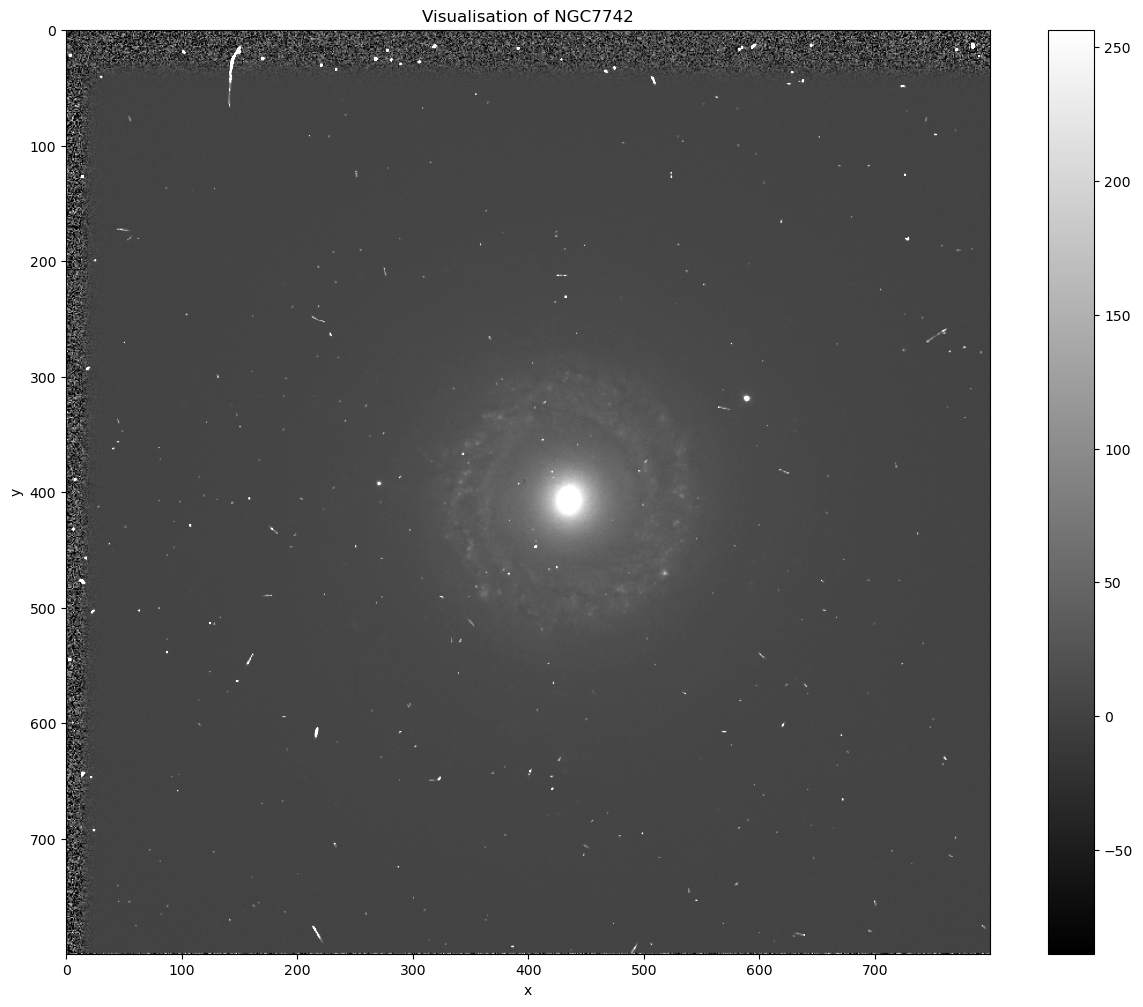

In [14]:
#call the functionm 
show_image (NGC7742_675_image)

Using this function, we have successfully shown the galaxy in the image. We can see that this galaxy is spiral and almost in the centre of the image. We can also encounter some cosmic ray bombarding at the edges of the image. Verifying that this galaxy is spiral will be crucial in the subsequent fitting of circular masks later in the task. 

## Task 2: Image prep and mask definition

### 2.1: Finding center

We will now identify the centre of the galaxy. While more accurate methods could be used, we will do this by estimating the center based on the visualisation in part 1.3. There was an attempt to find the brightest pixel and identify that as the center of the galaxy, however with cosmic ray bombarding this method is rendered invalid. If this brings forth any limitations to the method further along, we will comment on it in the conclusion. 

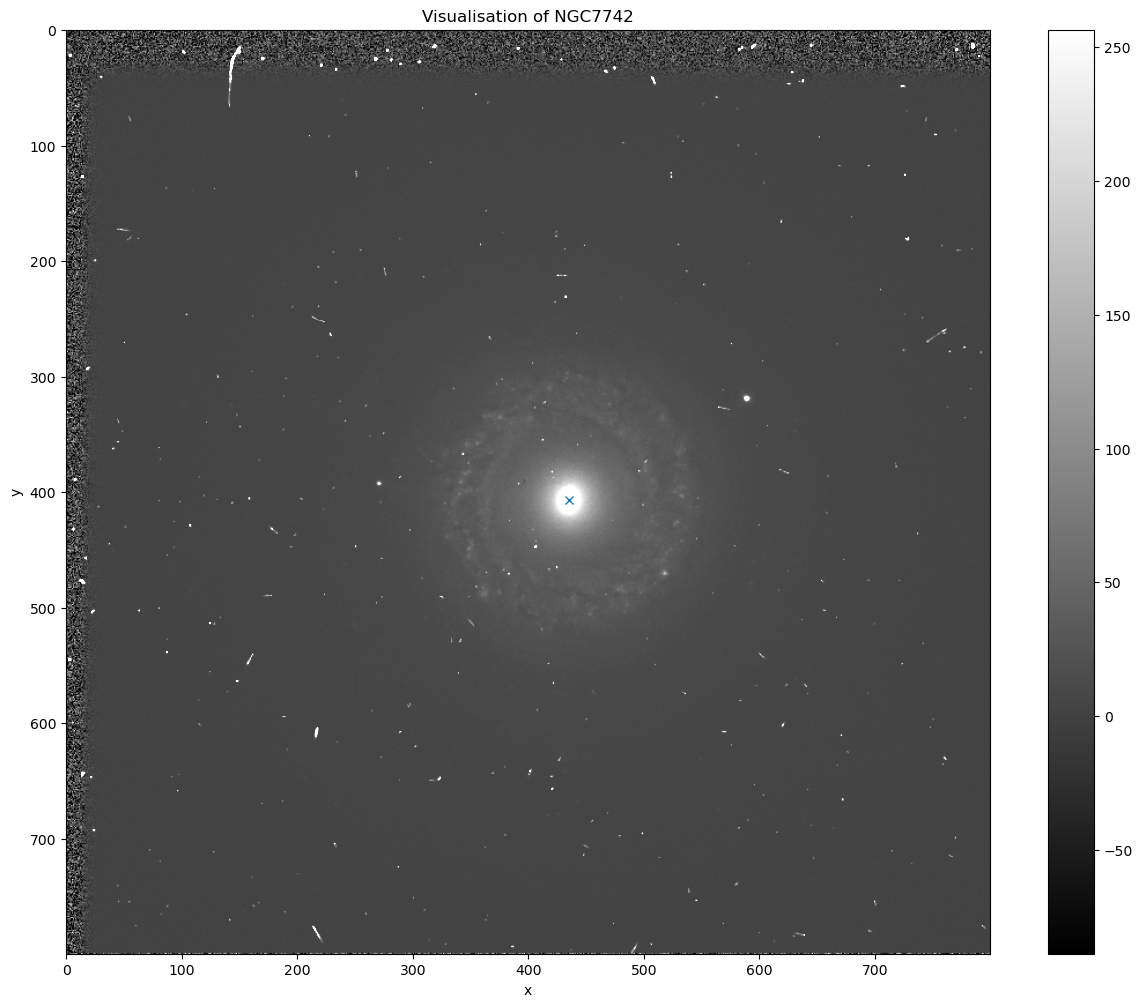

In [20]:
#hard code 

#run some stats
mean_galaxy = np.mean(NGC7742_675_image)
std_galaxy = np.std(NGC7742_675_image)
vmin_galaxy = mean_galaxy - 0.5 * std_galaxy
vmax_galaxy = mean_galaxy + 1.25 * std_galaxy

#centre of galaxy estimate
x_centre = 435
y_centre = 407

#plot to confirm image centre
plt.figure ()
plt.imshow(NGC7742_675_image, cmap='gray', vmin=vmin_galaxy, vmax=vmax_galaxy) # or we can set vmin = 0, vmax = 100
plt.plot (x_centre, y_centre, "x")
plt.title ('Visualisation of NGC7742')
plt.xlabel('x')
plt.ylabel ('y')
plt.colorbar()
plt.show()


In [22]:
print (f"The x-centre is: {x_centre}")
print (f"The y-centre is: {y_centre}")

The x-centre is: 435
The y-centre is: 407


### 2.2: Subtracting background offset

We should now identify the "background noise" of the image. This will be done flattening our data array and plotting its histogram to find the mode value. This value will then be subtracted from our image data as an offset.

In [26]:
#flatten the data
galaxy_flat = NGC7742_675_image.flatten()

#check if it is flatten
print(galaxy_flat.shape)

(640000,)


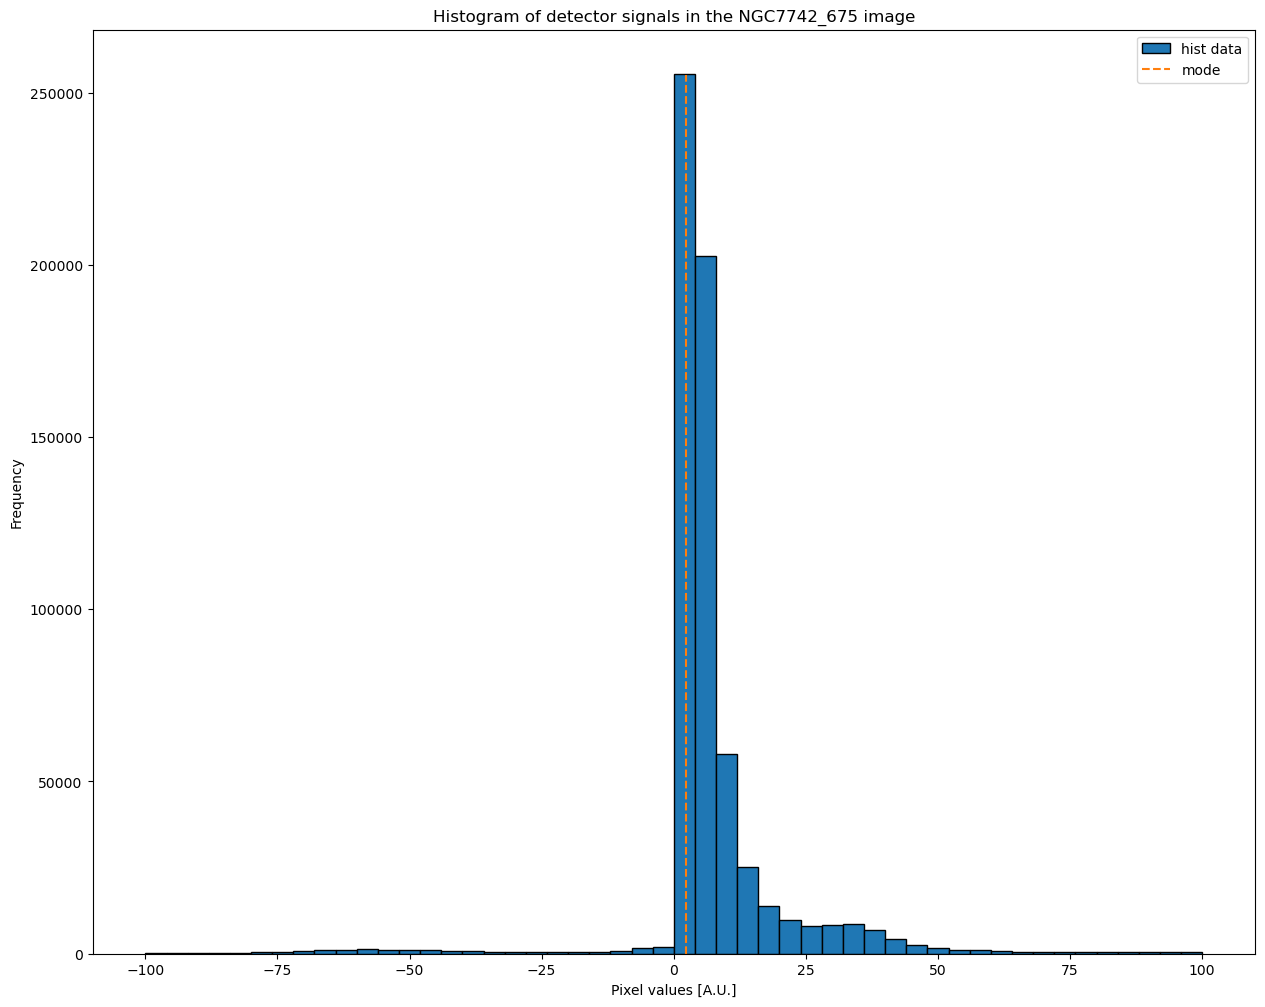

In [28]:
#plot the histogram 
plt.hist (galaxy_flat, bins = 50, edgecolor = 'black', range = (-100,100), label = 'hist data') #specify range of hist
plt.plot((2.4, 2.4), (0,255000), "--" , label = 'mode')
plt.xlabel('Pixel values [A.U.]')
plt.ylabel('Frequency')
plt.title ('Histogram of detector signals in the NGC7742_675 image')
plt.legend()


In [30]:
#mode as found above
mode = 2.4 #noise

#subtracting the offset 
subtracted_galaxy = NGC7742_675_image - mode

With a noise-subtracted data we can now proceed with our task to conduct aperture photometry on the galaxy.

### 2.3: Masks and definition of a geometrical locus

Before conducting photometery, we will have to create a mask on our data. In this section we simply explore how masks work and see that we can apply various functions to them.

In [35]:
# To create the 2D equivalent of our usual 1D x vectors, we will use a handy way of 
# creating "x" and "y" accompanying arrays that allow us
# to create masks or other surfaces in 2D by simple algebric operations

# Let's choose a size of such arrays (this can arbitrarily be changed by you according to your needs)
# Beware that the larger the size, the longer it might take for a machine to compute each operation you perform

size=100

# The following creates a size^2 array from "0" to "size" and then rearranges it 
# so its counting along columns and then up 1 row at a time
temp  = np.linspace(0,(size*size-1.)/size,size*size)

# We then use the "reshape" command to rearrange this long 1D array of values to make a square array
temp2 = np.reshape(temp,(size,size))

# Now we use the raster scan array obtained to create two arrays which are respectively the "x" and the "y" of 
# any 2D square image we want with "size" as its side.

yy = np.floor(temp2)     # floor truncates the array (as pixel values are integers)
temp3 = (temp2-yy)*size
xx = np.round(temp3)


In the following cell, I created four plots so you can see better understand the nature of the variables we just created:

Text(0.5, 1.0, 'yy')

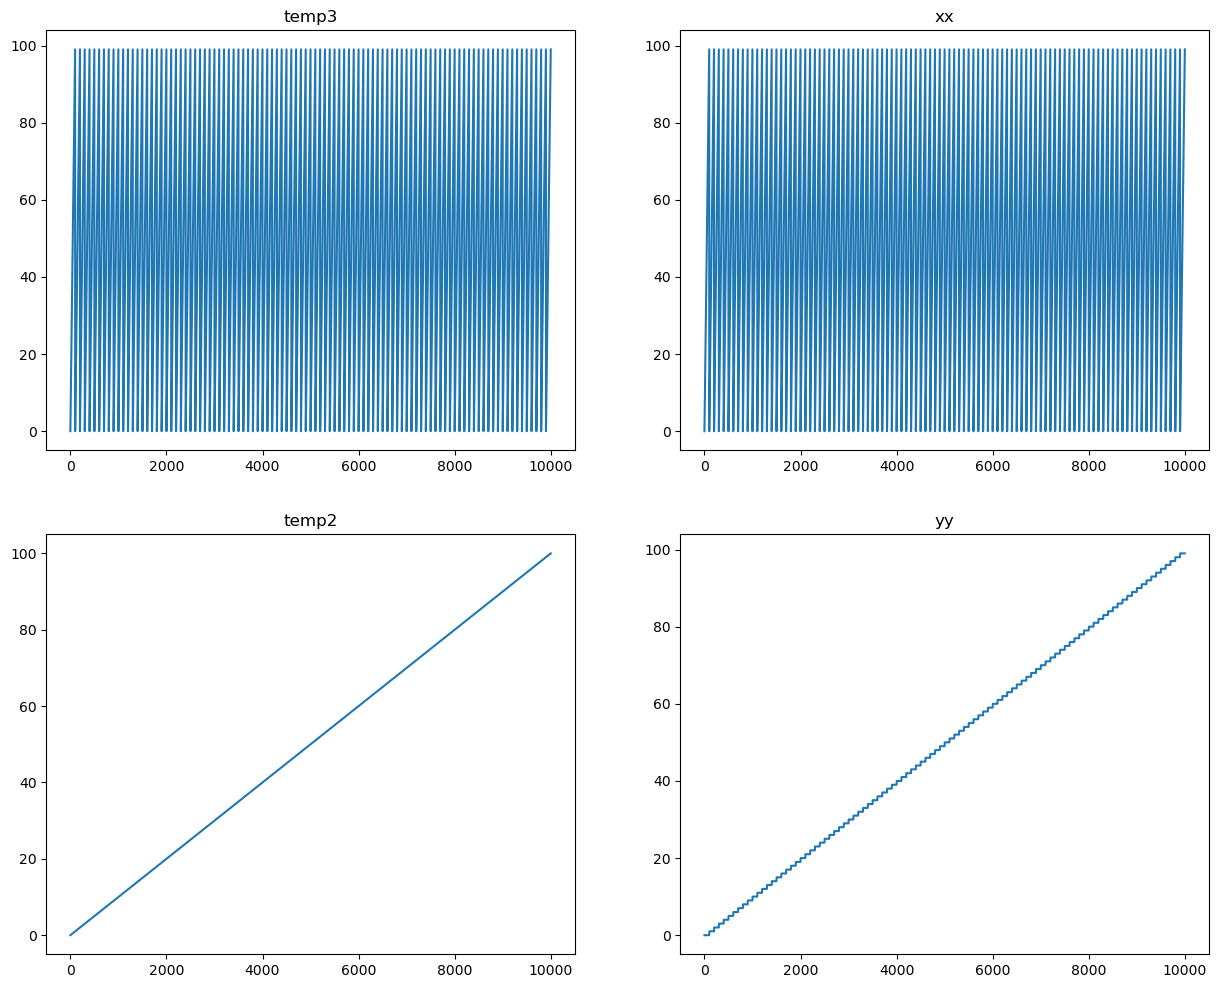

In [38]:
# STUDENT GENERATED CELL #
fig , pls = plt.subplots(2,2)
pls[0,0].plot(temp3.flatten()) 
pls[0,1].plot(xx.flatten()) 
pls[1,0].plot(temp2.flatten()) 
pls[1,1].plot(yy.flatten()) 

pls[0,0].set_title('temp3') 
pls[0,1].set_title('xx')
pls[1,0].set_title('temp2')
pls[1,1].set_title('yy')

Likewise in the following cell one can see the actual equivalent "images" of these coordinates that map their own values.

Text(0.5, 1.0, 'yy')

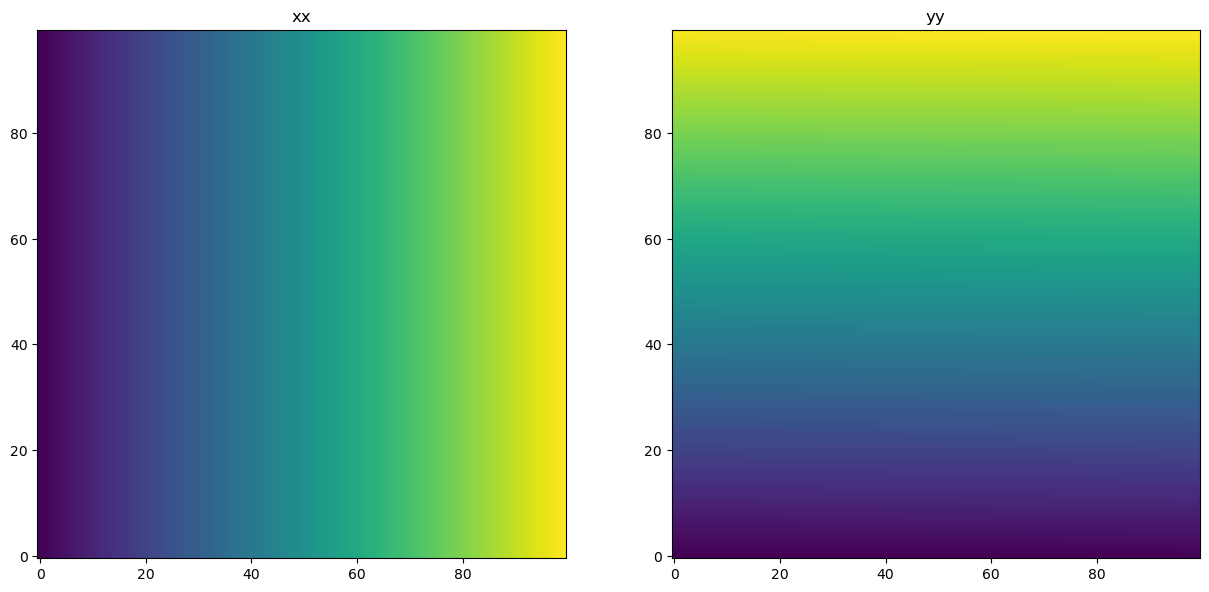

In [41]:
fig , plb = plt.subplots(1,2)
 
plb[0].imshow(temp3, origin='lower') 
plb[1].imshow(temp2, origin='lower')  

plb[0].set_title('xx') 
plb[1].set_title('yy')

We apply the same set of rules to find a distance from a point and then plot it:

Text(0, 0.5, 'y')

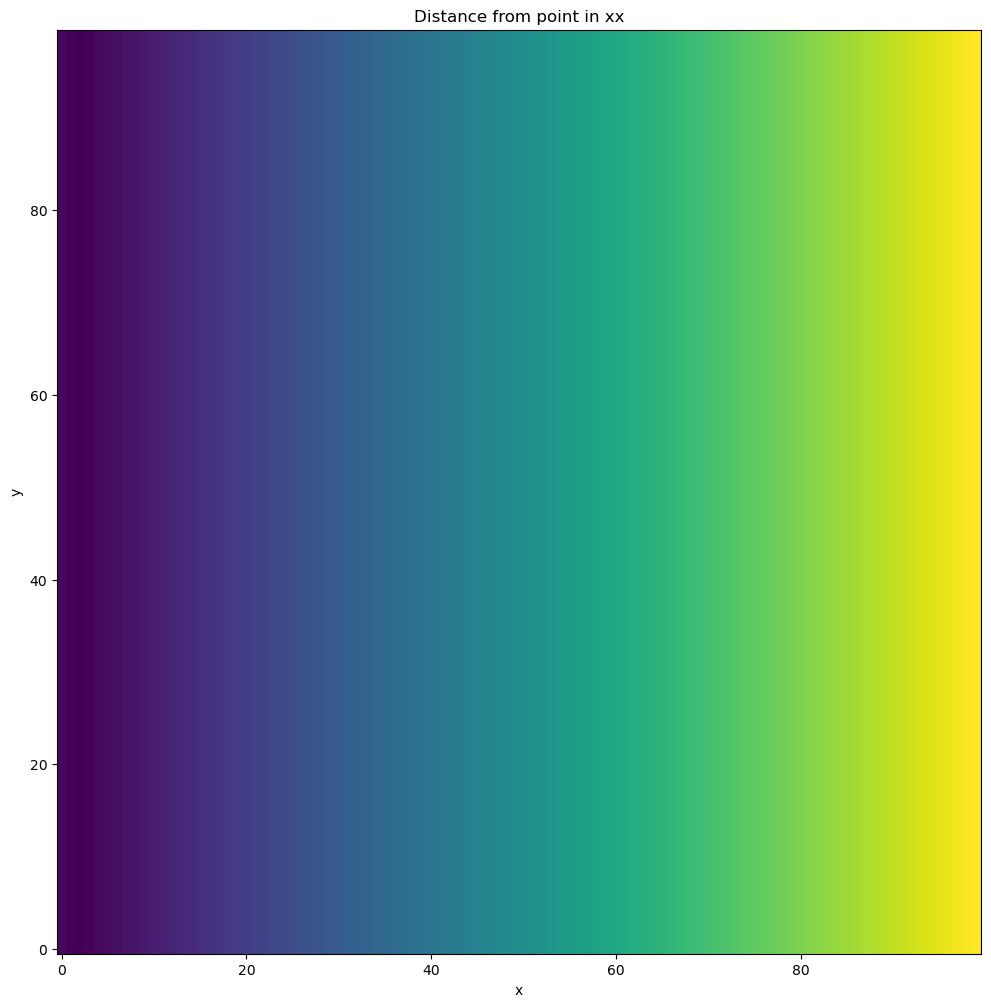

In [44]:
#distance from a point 
temp4 = np.sqrt((xx - 2)**2)
plt.imshow (temp4, origin='lower')
plt.title('Distance from point in xx')
plt.xlabel ('x')
plt.ylabel ('y')

### 2.4: Applying other mathematical functions

Let us now solidify our understanding of masks by trying to apply other mathematical functions to our predefined arrays of xx and yy:

Text(0, 0.5, 'y')

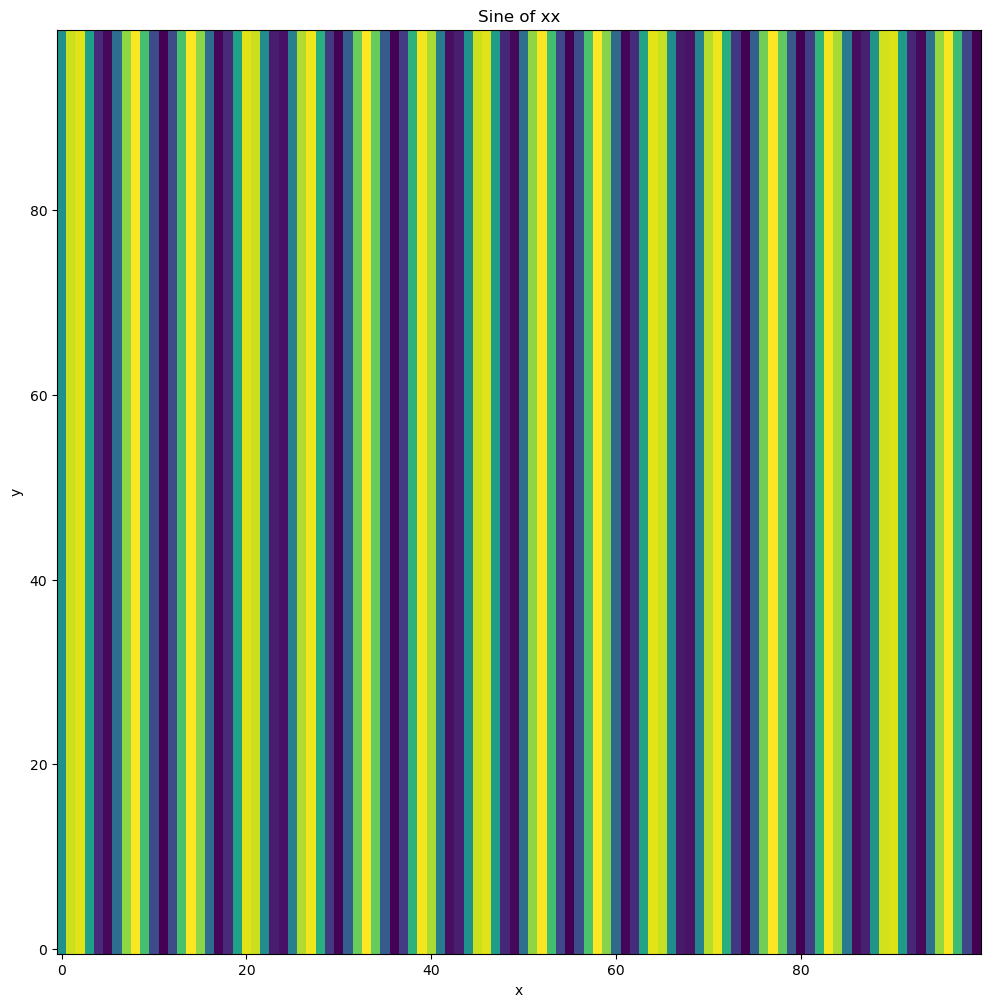

In [48]:
### STUDENT GENERATED CELL ###

#applying a sine function 
temp5 = np.sin(xx)
plt.imshow (temp5, origin='lower')
plt.title('Sine of xx')
plt.xlabel ('x')
plt.ylabel ('y')

### 2.5: Creating masks for galaxy

We now apply our understanding about masks to create a mask for the galaxy in our FITS image. We apply the same logic but change size of the mask to correspond to the number of pixels in our FITS image (800 x 800).

In [52]:
#number of pixels in xx and yy in FITS image
size=800

# The following creates a size^2 array from "0" to "size" and then rearranges it 
# so its counting along columns and then up 1 row at a time
temp  = np.linspace(0,(size*size-1.)/size,size*size)

# We then use the "reshape" command to rearrange this long 1D array of values to make a square array
temp2 = np.reshape(temp,(size,size))

# Now we use the raster scan array obtained to create two arrays which are respectively the "x" and the "y" of 
# any 2D square image we want with "size" as its side.

yy = np.floor(temp2)     # floor truncates the array (as pixel values are integers)
temp3 = (temp2-yy)*size
xx = np.round(temp3)

We will now create a function "mask" that will create a circular mask on the galaxy of different radii. The mask will apply boolean logic, and set all the values inside of the radius to 'True' and all values outside to 'False'. Let us then overlay this on our image for visual confirmation.

In [55]:
#function to create mask
def mask (x_centre, y_centre, r):
    """Creates mask on circualr region over a spiral galaxy. 
    Input:
    x_centre = x-coord centre of galaxy
    y_centre = y-coord centre of galaxy
    r = radius of circular mask
    
    Output:
    Boolean array specifiying regions inside and outside of the mask 
    """

    #distance from centre of galaxy
    distance = np.sqrt((xx - x_centre)**2 + (yy - y_centre)**2)

    #condition
    circular_mask = distance <= r
    return circular_mask 

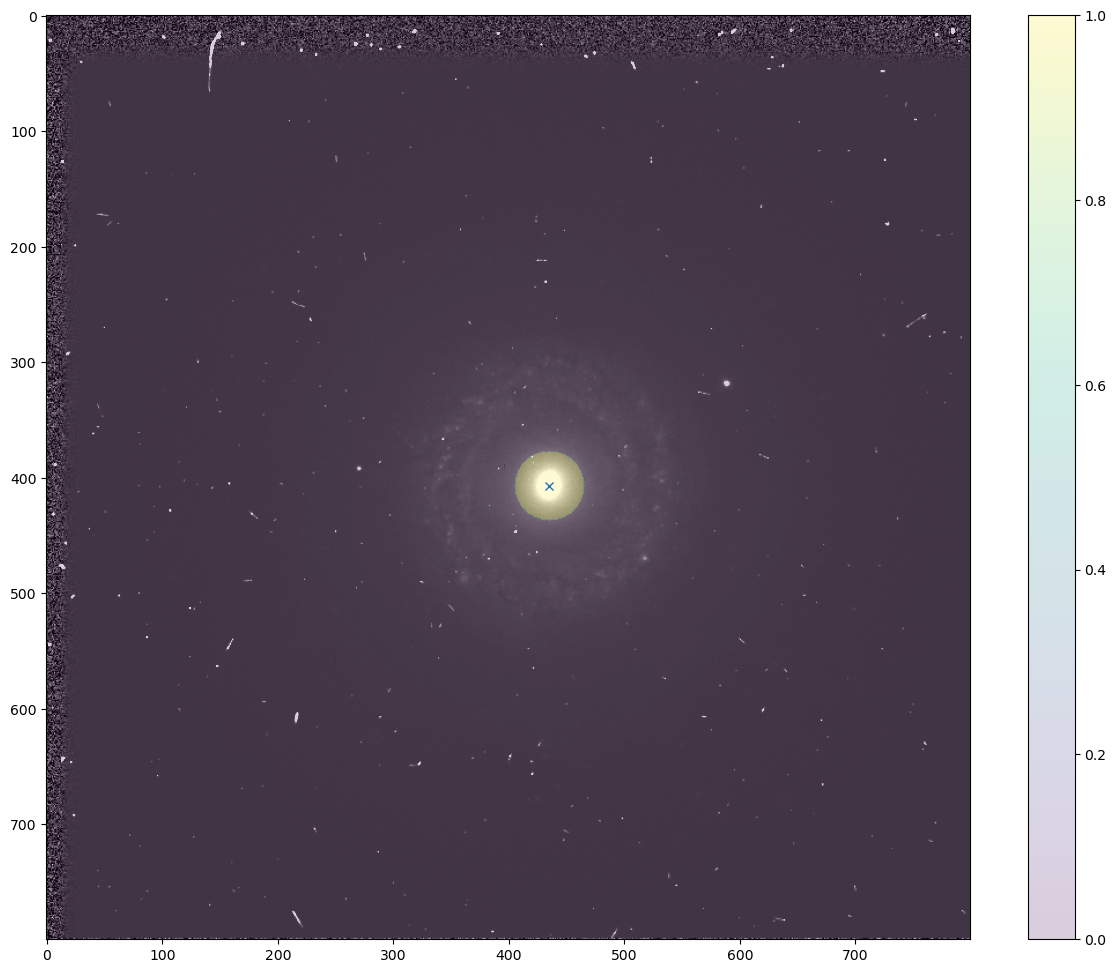

In [57]:
#call the function
mask1 = mask (435, 407, 30)

#plot the mask
plt.figure ()
plt.imshow(subtracted_galaxy, cmap='gray', vmin=vmin_galaxy, vmax=vmax_galaxy) # or we can set vmin = 0, vmax = 100
plt.imshow (mask1, alpha = 0.2)
plt.plot (x_centre, y_centre, "x")
plt.colorbar()
plt.show()

After plotting, we see that our function works as it creates a circular mask of radius specified on the user and applies it to the galaxy. This will now allow us to apply masks of many radii to find flux in different regions of the galaxy. 

## Task 3: Aperture photometry

### 3.1: Creating masks for various radii and obtaining values of flux

We will now create a series of masks ranging from a radius of 5 to 200 pixels. This will be done in a loop that will call the function created in section 2.5. We will store the values of radii, flux (sum of signals in mask region) and number of pixels in separate arrays. 

In [63]:
 ### STUDENT GENERATED CELL ###

#empty arrays where we will append our 
rad = np.array([])
flux = np.array([]) #sum of signals in the region
n_pix = np.array([])

#loop for radii 5 - 200 pixels 
for kr in range (5,200):
    rad = np.append(rad,kr)                      #appends used radius
    mask_flux = mask (435, 407, kr)              #calls mask function
    signal = subtracted_galaxy * mask_flux       # calculates signal
    signal_sum = np.sum(signal)                  #sums all signals to find flux 
    flux = np.append (flux,signal_sum)           #appends to flux 
    n_pix = np.append (n_pix, np.sum(mask_flux)) #appends sum of pixels in mask area to n_pix
    

With our created arrays, we can then proceed to find intensities and conduct analysis on how intensity changes with distance from the centre of the galaxy. 

### 3.2: 1-point derivative

We now have to identify the intensity in each ring area of the circular aperture to be able to apply a Sersic model to our data. This will be done shifting the values in flux and n_pix by one and didving the array through to find the 1-point derivative. 

Text(0.5, 1.0, 'Plot of Surface brightness VS Radius')

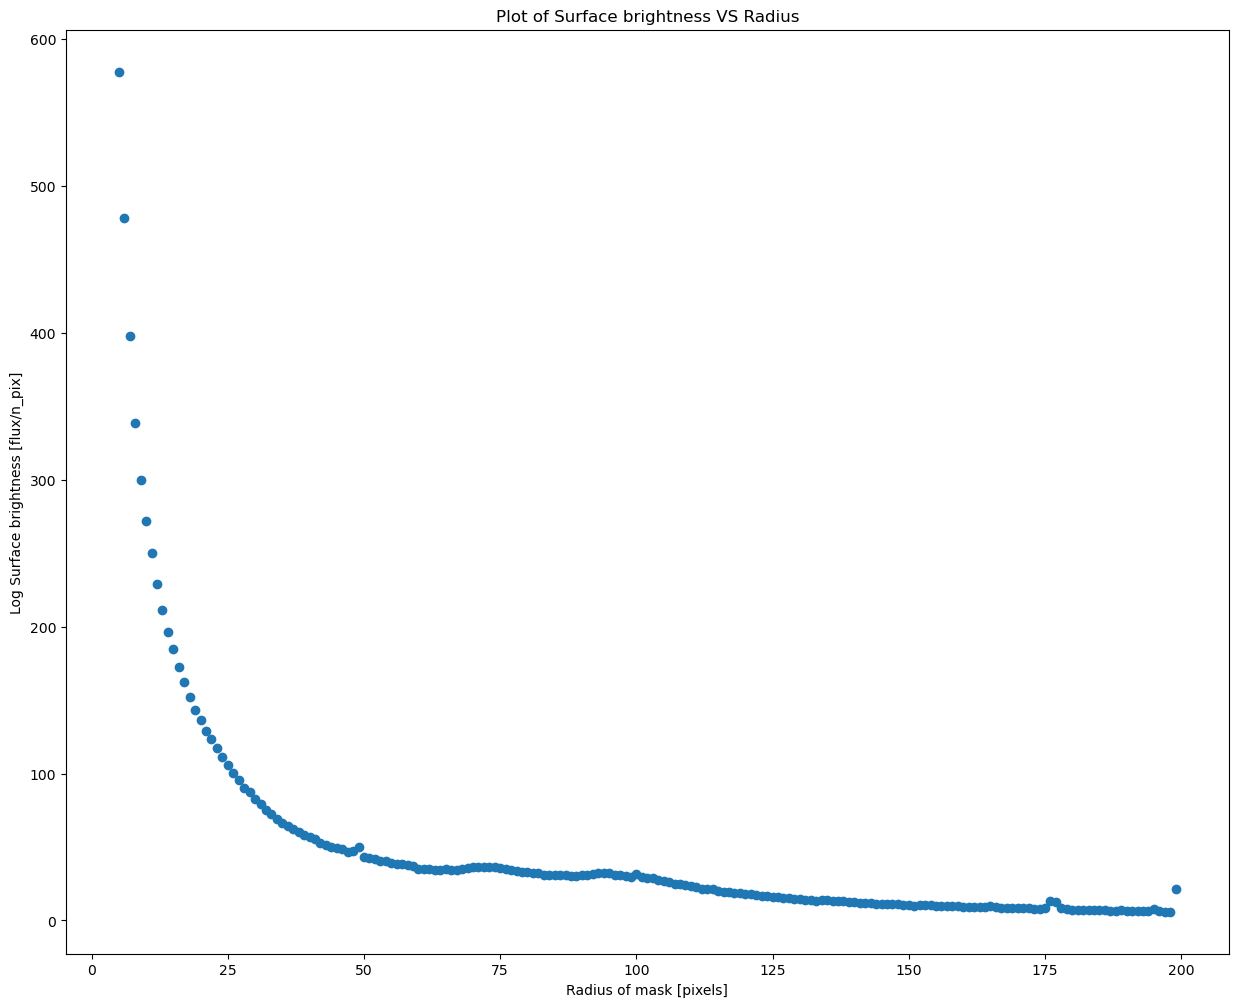

In [68]:
#shifting values in arrays 
flux_shift = np.append(flux[1:], flux[0])
n_pix_shift = np.append(n_pix[1:], n_pix[0])

# 1-point derivative 
onepointderivative = (flux - flux_shift) / (n_pix - n_pix_shift) # you need to add the last element


#plot
plt.plot (rad, onepointderivative, "o")
plt.xlabel('Radius of mask [pixels]')
plt.ylabel('Log Surface brightness [flux/n_pix]')
plt.title ('Plot of Surface brightness VS Radius' )

The graph above shows us that the surface brightness can be approximately modelled by a decreasing exponential. This makes sense as the further we go away from our galaxy center, the less flux we expect. We see that in regions for radius 5 - 30 the function is steeply decreasing as this is the galaxy centre. From 30 - 100, we see the function still decreases in surface brigthness, indicating that the spiral arms are almost uniform but still there is a change in brightness. From 100 - 200, we are already outside of the galaxy region and intensity is almost constant. In this region we also see a couple of data points that do not fit the designated trend  but this could be explained by bright outlier pixels (stars or cosmic rays) that could be removed if we wanted to obtain a more accurate fit in further sections. 

Let us also plot the graph with taking a log of the y-axis. This will proof to be useful later in the task and will allow us to see deviations from the exponential lightly better:

Text(0.5, 1.0, 'Plot of Log of Surface brightness VS Radius')

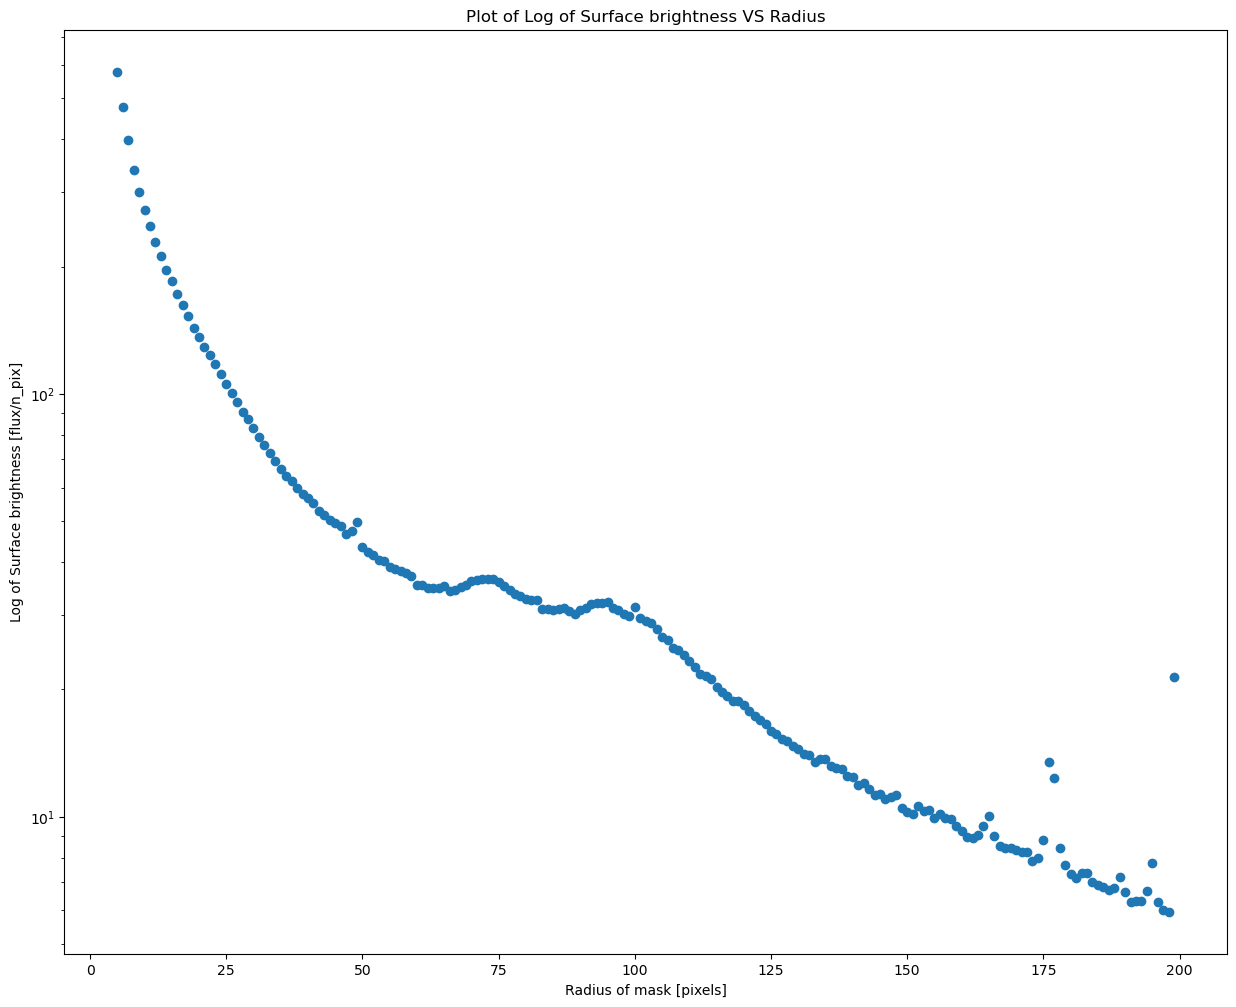

In [72]:
#log plot
plt.plot (rad, onepointderivative, "o")
plt.xlabel('Radius of mask [pixels]')
plt.ylabel('Log of Surface brightness [flux/n_pix]')
plt.yscale('log')
plt.title ('Plot of Log of Surface brightness VS Radius' )

### 3.3 & 3.4: Creating a function with a Sersic profile

We will now use create a function that fits a Sersic profile to our data. The Sersic profile if given by: $$ I(R)= I_e e^{-b_n[(\frac{R}{Re})^{\frac{1}{n}}-1]}$$

Where:
- I_e: is the intensity at Re 
- Re: is half-light radius (pixels)
- $b_n \approx 2n-1/3$, for $n>8$ (and a more convoluted expression can be found in the wiki link above)
- n is Sérsic index (int) that controls the degree of curvature of the profile

In [76]:
#function for the sersic profile

def sersic_profile(R, i_e, R_e, n):
    """This function plots a sersic profile
    Input:
    R = radius array 
    i_e = intensity at Re (x)
    Re = half light radius in pixel (y)
    n = sersic index
    
    Output:
    Sersic profile"""

    b_n = (2*n - (1/3))
    sersic = i_e * np.exp(-b_n * ((R/R_e)**(1/n) - 1))
    
    return sersic



Using our function, we can now plot the Sersic profile for various values of $I_e$:

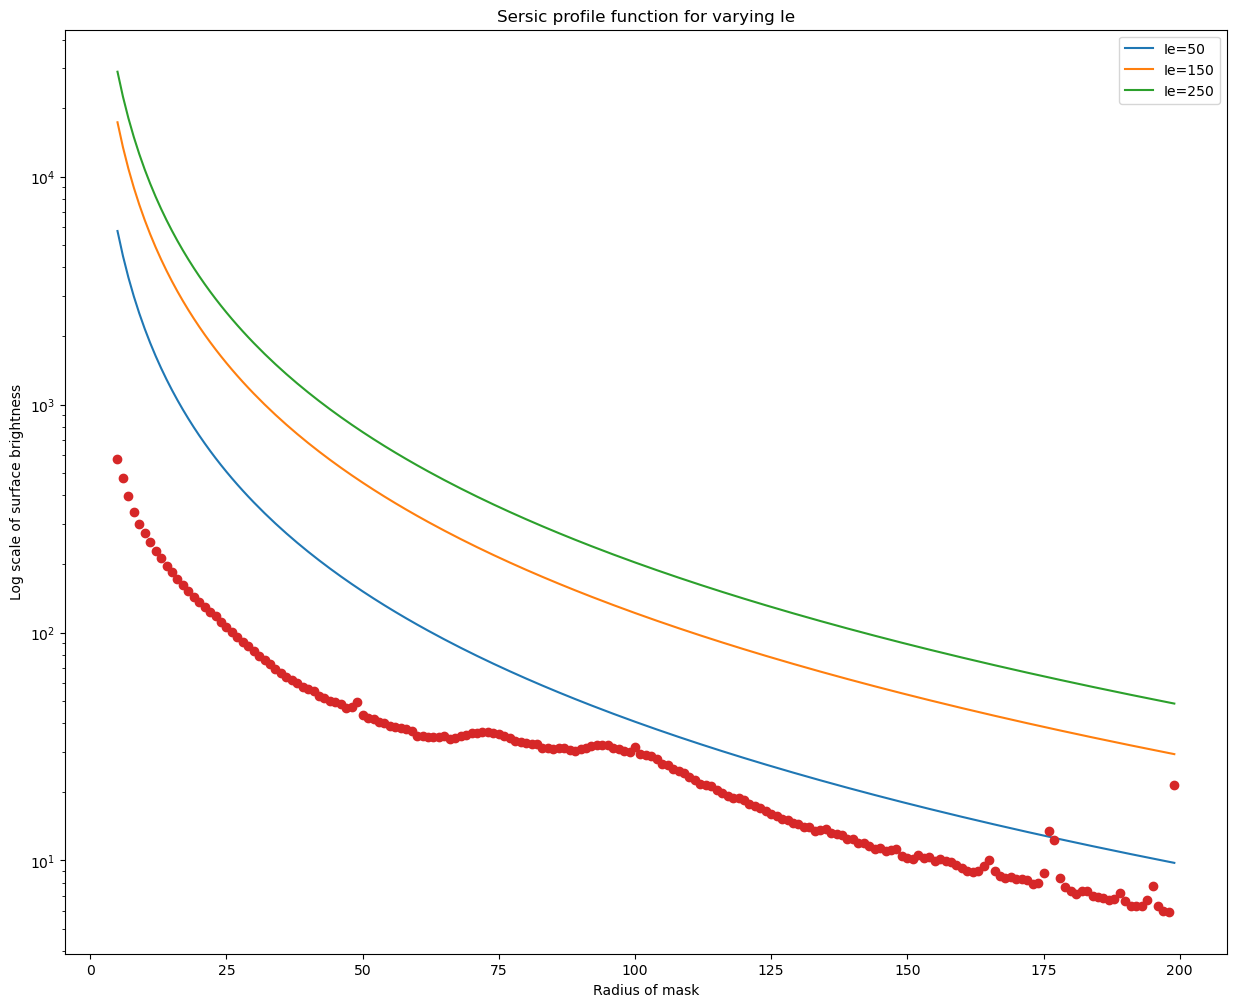

In [79]:
#estimating the constants
R_e = 90.
n = 8

#varrying I_e
for I_e in [50, 150, 250]:
    plt.plot(rad, sersic_profile(rad, I_e, R_e, n), label=f"Ie={I_e}")
    plt.xlabel('Radius of mask')
    plt.ylabel('Log scale of surface brightness')
    plt.title ('Sersic profile function for varying Ie')
    plt.yscale('log')
    plt.legend()

plt.plot (rad, onepointderivative, "o", label = "data points")

From these curves we can see that $I_e$ is responsible for rescaling the surface brightness of the Sersic profile. 

Graphing the Sersic profile for various values of $R_e$:

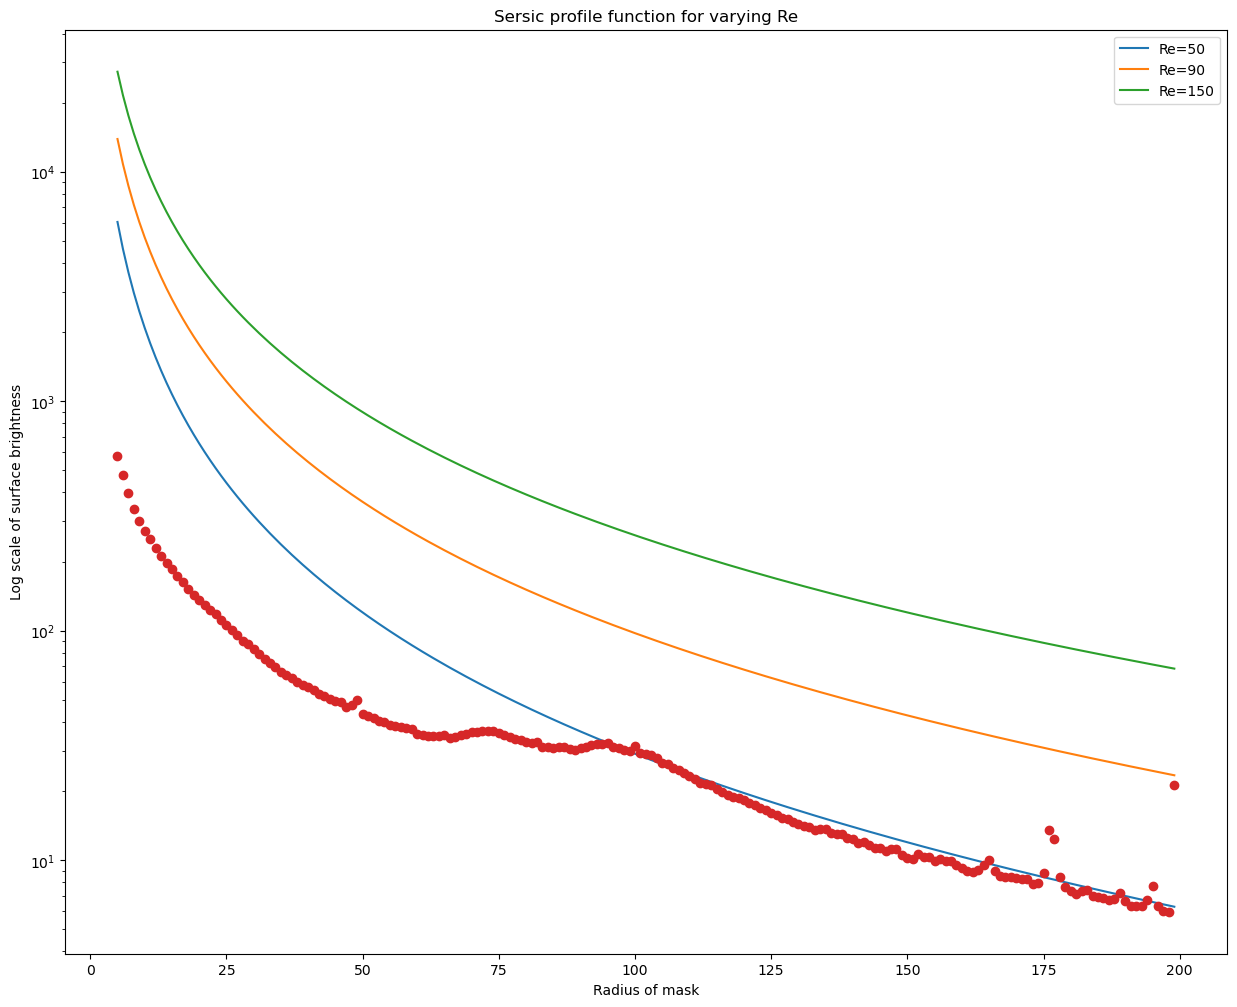

In [83]:
#estimating the constants
I_e = 120.
n = 8

#varrying R_e
for R_e in [50, 90, 150]:
    plt.plot(rad, sersic_profile(rad, I_e, R_e, n), label=f"Re={R_e}")
    plt.xlabel('Radius of mask')
    plt.ylabel('Log scale of surface brightness')
    plt.title ('Sersic profile function for varying Re')
    plt.yscale('log')
    plt.legend()

plt.plot (rad, onepointderivative, "o", label = "data points")

We see that R_e is responsible for the horizontal streching of the Sersic fit. 

Graphing the Sersic profile for various values of $n$:

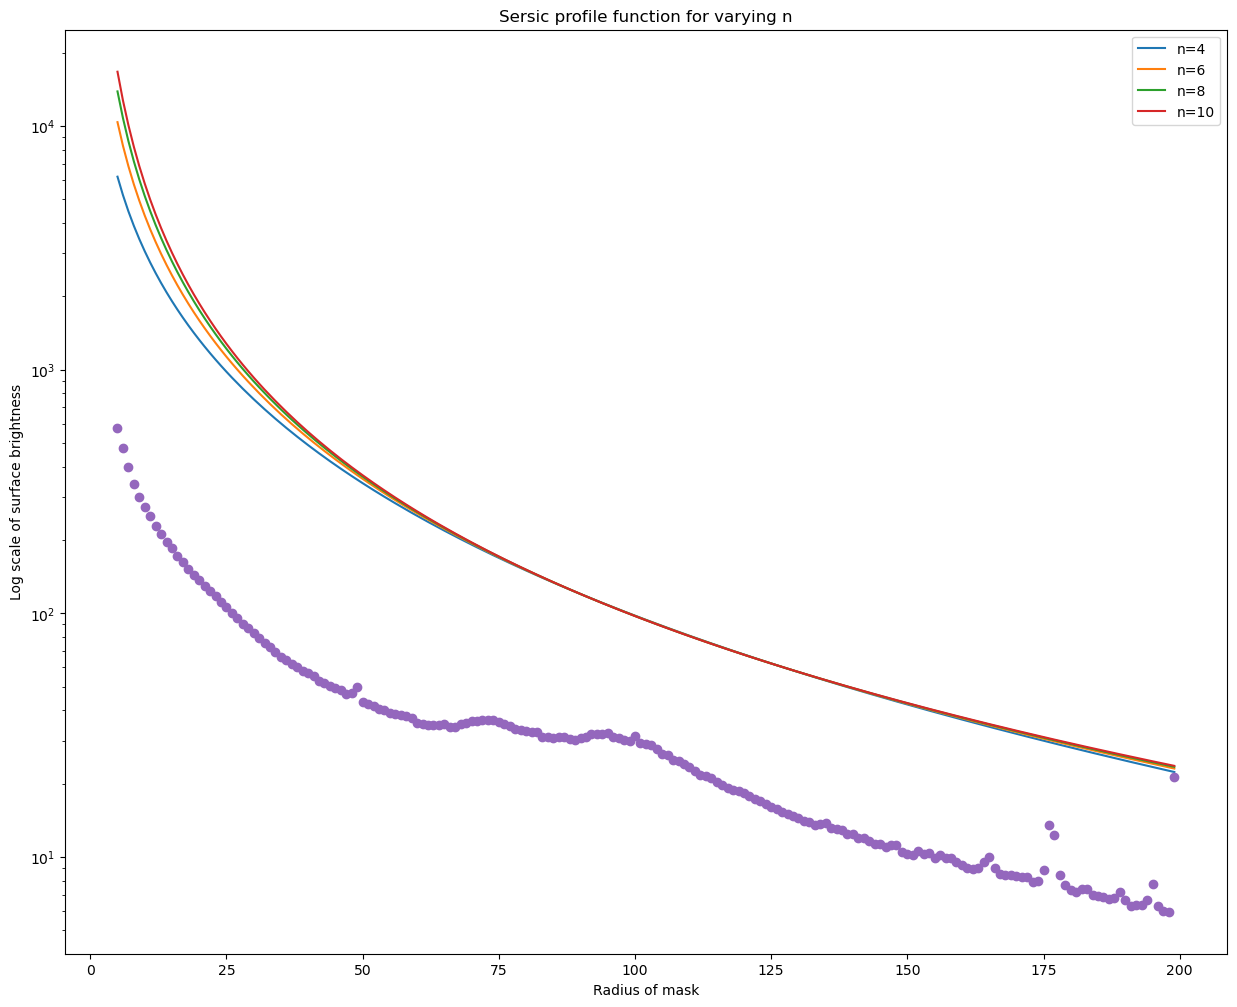

In [87]:
#estimating the constants
I_e = 120.
R_e = 90.

#varrying n
for n in [4, 6, 8, 10 ]:
    plt.plot(rad, sersic_profile(rad, I_e, R_e, n), label=f"n={n}")
    plt.xlabel('Radius of mask')
    plt.ylabel('Log scale of surface brightness')
    plt.title ('Sersic profile function for varying n')
    plt.yscale('log')
    plt.legend()

plt.plot (rad, onepointderivative, "o", label = "data points")

As we could already infer from the task instructions, the value of n matches the shape of the curve itself and gives the characteristic shape of the Sersic profile. 

Let us now apply an individual sersic fit to each part of the curve (i.e. 0-30, 30-100 & 100,200). We will estimate the most suitable values of I_e, R_e and n based on the investigation we did above. 

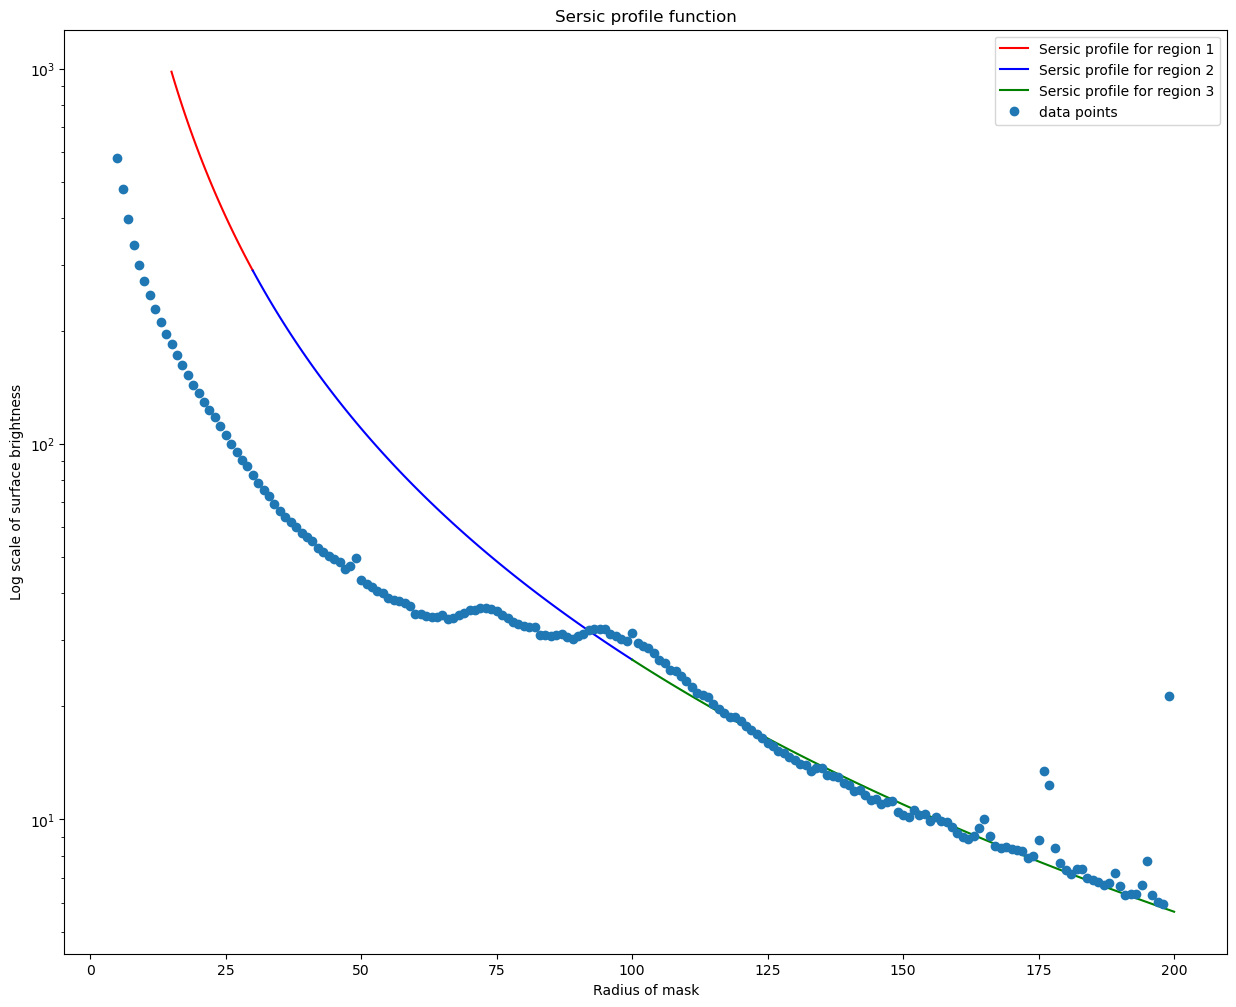

In [91]:
#divide x-axis into regions 
x_1 = np.linspace(15,30,100)
x_2 = np.linspace(30,100,100)
x_3 = np.linspace(100,200,100)

#estimating the constants
i_e_estimate = 110.
R_e_estimate = 50.
n_estimate = 8

#plotting the profiles
plt.plot (x_1, sersic_profile(x_1, i_e_estimate, R_e_estimate, n_estimate), label = "Sersic profile for region 1", color = 'red')
plt.plot (x_2, sersic_profile(x_2, i_e_estimate, R_e_estimate, n_estimate), label = "Sersic profile for region 2", color = 'blue')
plt.plot (x_3, sersic_profile(x_3, i_e_estimate, R_e_estimate, n_estimate), label = "Sersic profile for region 3", color = 'green')
plt.plot (rad, onepointderivative, "o", label = "data points")
plt.xlabel('Radius of mask')
plt.ylabel('Log scale of surface brightness')
plt.title ('Sersic profile function')
plt.yscale('log')
plt.legend()

We see that while this fit estimates the profile well for the last region, the first two parts are not fitted that well. This implies that we will need to set up a separate sersic profile for each region if we hope to gain some feasible results. The different fit of these regions is due to the nature they represent within the galaxy, as already discussed in a previous markdown cell. 

## Task 4: Sérsic plot fitting

Now [4.1] Create a function that fits, using "optimize.curve.fit" as we have done before, the Sersic profile function to different parts of the obtained profile.

### 4.1: Finding parameters through optimize.curve.fit

In this section we will create a function that will properly fit the parameters of the Sersic profile by using 'optimize.curve.fit".

In [98]:
#fitting a log function sersic fit 
def fitting_sersic (x_range, y_range, n_guess):
    """This function fits the coefficients of the sersic profile based on provided 
    estimates and creates a plot for separate regions of the fit.
    Input:
    x_range = radius range 
    y_range = surface intensity range 
    n = estimate for n value"""

    #masking
    masking = np.isfinite (x_range) & np.isfinite(y_range) & (y_range > 0) & (x_range > 0)
    x_val = x_range [masking]
    y_val = y_range [masking]

    #parameters 
    Re_guess = np.median (x_val)
    Ie_guess = np.median (y_val)
    
    #boundaries
    boundaries = ([1e-12, 1e-6, 0.3], [np.inf, np.inf, 20])

    line_par_s , line_cov_s = optimize.curve_fit(sersic_profile, x_val, y_val, p0=[Ie_guess, Re_guess, n_guess], bounds = boundaries, maxfev=20000)
    print(f"The coeffs i_e, r_e, n are: {line_par_s}")
    
    ie_err, re_err, n_err = np.sqrt(np.diag(line_cov_s)) 
    print (f"The error on the coeffs i_e, r_e, n are: {ie_err, re_err, n_err}")

    line_shape_s = sersic_profile(x_val,line_par_s[0],line_par_s[1],line_par_s[2])

    #plot 
    plt.semilogy (x_val, y_val, 'o', label = 'Data points')
    plt.plot(x_val, line_shape_s, label = 'Sersic fit')
    plt.xlabel('Radius of mask')
    plt.ylabel('Log scale of surface brightness')
    plt.title ('Sersic profile function')
    plt.yscale('log')
    plt.legend()

    return line_par_s, line_cov_s
        



The coeffs i_e, r_e, n are: [2.29742062e-06 3.17268294e+06 2.00000000e+01]
The error on the coeffs i_e, r_e, n are: (1.4883761638336866e-07, 1.1570993320656862e-07, 0.2341531868965478)
The coeffs i_e, r_e, n are: [5.16136409e-10 2.93298950e+10 2.00000000e+01]
The error on the coeffs i_e, r_e, n are: (1.9915191512472664e-10, 2.4326540756521485e-11, 0.7197540304914964)
The coeffs i_e, r_e, n are: [829.88016735  19.16353949  20.        ]
The error on the coeffs i_e, r_e, n are: (31201.533998737123, 344.16723845872895, 198.10125722220218)


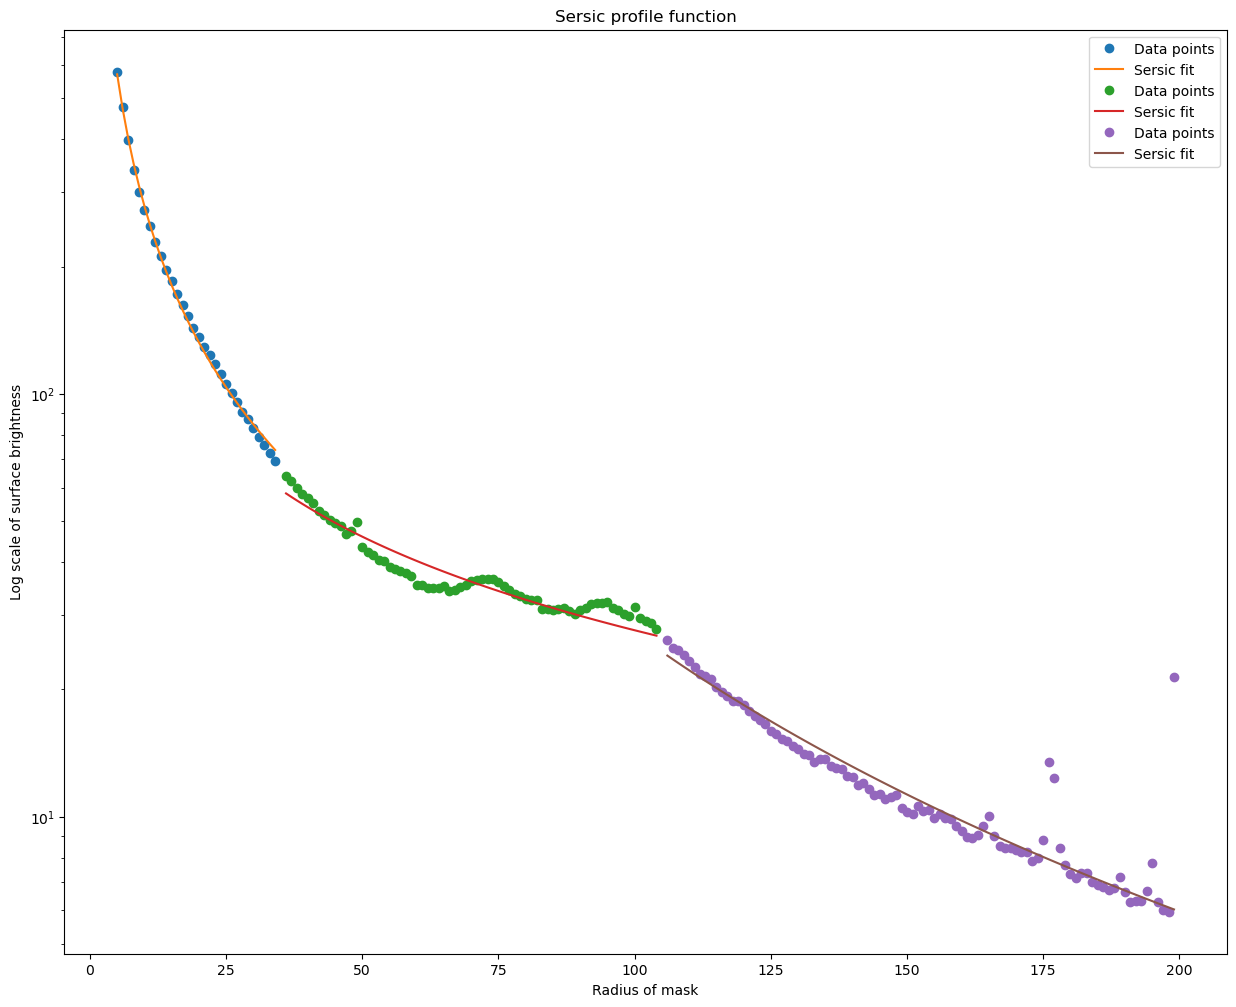

In [100]:
#call the function 
rad1 = rad [0:30]
intensity1 = onepointderivative [0:30]
fit1 = fitting_sersic (rad1, intensity1, 4)

#call the function 
rad2 = rad [31:100]
intensity2 = onepointderivative [31:100]
fit2 = fitting_sersic (rad2, intensity2, 2)

#call the function 
rad3 = rad [101:200]
intensity3 = onepointderivative [101:200]
fit3 = fitting_sersic (rad3, intensity3, 1)


We see that by fitting a Sersic profile to each region separately, we obatin a much better fit for each region, compared to what we obtained in section 3.4. Let us print the results properly:

In [103]:
#coeffs for region 1 
Ie_1 = 2.29742062e-06
Re_1 = 3.17268294e+06
n1 = 2.00000000e+01

Ie1_err = 1.4883761638336866e-07
Re1_err =  1.1570993320656862e-07
n1_err = 0.2341531868965478

#coeffs for region 2 
Ie_2 = 5.16136409e-10
Re_2 = 2.93298950e+10
n2 = 2.00000000e+01

Ie2_err = 1.9915191512472664e-10
Re2_err = 2.4326540756521485e-11
n2_err = 0.7197540304914964

#coeffs for region 3 
Ie_3 = 829.88016735
Re_3 =  19.16353949
n3 = 20

Ie3_err = 31201.533998737123
Re3_err = 344.16723845872895
n3_err = 198.10125722220218

#clearly print our results
print (f"The coeffs for region 1 are: I_e = {Ie_1} ± {Ie1_err}, R_e = {Re_1:.5f} ± {Re1_err:.3f}, n = {n1:.3f} ± {n1_err:.3f},")
print (f"The coeffs for region 2 are: I_e = {Ie_2} ± {Ie2_err}, R_e = {Re_2:.5f} ± {Re2_err:.3f}, n = {n2:.3f} ± {n2_err:.3f},")
print (f"The coeffs for region 3 are: I_e = {Ie_3} ± {Ie3_err}, R_e = {Re_3:.3f} ± {Re3_err:.3f}, n = {n3:.3f} ± {n3_err:.3f},")




The coeffs for region 1 are: I_e = 2.29742062e-06 ± 1.4883761638336866e-07, R_e = 3172682.94000 ± 0.000, n = 20.000 ± 0.234,
The coeffs for region 2 are: I_e = 5.16136409e-10 ± 1.9915191512472664e-10, R_e = 29329895000.00000 ± 0.000, n = 20.000 ± 0.720,
The coeffs for region 3 are: I_e = 829.88016735 ± 31201.533998737123, R_e = 19.164 ± 344.167, n = 20.000 ± 198.101,


We see that the numerical values we obtain do seem rather strange, but this might be gven by the log plot. In the graph, the profiles approximate their regions rather well. To verify the goodness of these fits, let us compute the $\chi^2$ reduced for each profile region. To find $\chi^2$ reduced we will use [1]:
$$
 \chi_{reduced}^2 = \frac{\chi^2}{K} = \frac{\sum_{i=1}^n(\frac{d_i}{\Delta y_i})^2}{K}
$$

Where $d_i$ is the calculated residual, $\Delta y_i$ is the error in distance measured and K is the degree of freedom given by:
$$
K = n - m
$$

Where n is th number of data points and m is the number of fit parameters.

To find residuals we will use[1]:

$$
d_i = y_{data} - y_{sersic}
$$


In [106]:
#apply our obtained coeffs

#region 1 
reg1 = sersic_profile(rad1, Ie_1, Re_1 , n1)
#region 2 
reg2 = sersic_profile(rad2, Ie_2, Re_2 , n2)
#region 3
reg3 = sersic_profile(rad3, Ie_3, Re_3 , n3)

In [108]:
#reduced chi squared function (from week 3 task)
def reduced_chisq (y, y_fit, y_err, num_parm):
    residuals = y - y_fit 
    chisq = np.sum((residuals/y_err)**2)
    k = len(y) - num_parm
    return chisq/k

In [110]:
#residuals 
res1 = intensity1 - reg1
res2 = intensity2 - reg2
res3 = intensity3 - reg3

#errors we take the std of residuals 
yerr1 = np.std(res1)
yerr2 = np.std(res2)
yerr3 = np.std(res3)

#chi sq reduced 
chisqred1 = reduced_chisq (intensity1, reg1, yerr1, 3)
print(f"The Chi squared reduced for the first region is {chisqred1:3f}")

chisqred2 = reduced_chisq (intensity2, reg2, yerr2, 3)
print(f"The Chi squared reduced for the second region is {chisqred2:3f}")

chisqred3 = reduced_chisq (intensity3, reg3, yerr3, 3)
print(f"The Chi squared reduced for the third region is {chisqred3:3f}")



The Chi squared reduced for the first region is 1.112240
The Chi squared reduced for the second region is 1.045822
The Chi squared reduced for the third region is 1.034031


Hence, the $\chi^2$ reduced evaluates the found Cersic fits as suitable to the data points as the values are close to 1. 

According to the Data Analysis and Statistics Booklet [1] a good fit is when we have a reduced $\chi ^2$ value close to 1. For all the profiles, we get a value very close to 1, which evalutes them as suitable fits. 

### 4.2: Sérsic index (n)

We can now evaluate how the functions Sersic index changes with radius from the centre of the galaxy. Commenting on our obtained n is rather difficult as the 'optimize.curve.fit' fitting predicted a value of n = 20 for each region. There might be a discrepancy in this due to the log plots though. When calling def fitting_sersic which uses 'optimize.curve.fit', we inputed an estimated value for each region of n. For the galaxy center, we used a value of n = 4, for the spiral arms n = 2 and for the background n = 1. It appears that our estimated values do in fact fit the expectations better, than the ones computed by 'optimize.curve.fit'. 

## Conclusion


To summarize, in this task we investiagted the flux of galaxy NGC7742 in a FITS image. We applied masks to create circular regions that may be considered as apertures. For different radii of these regions we computed the flux and number of pixels within the aperture. Using our obtained arrays, we then found the surface intensity that we plotted as a function of radius from the center of the galaxy. 

We approximated our results to a Sersic profile. First we explored properties of this profile through plotting various plots, leading us to estimate parameters of the Sersic profile. Through this exercise we also learned that it is necessary to divide our intesnity data based on the region of the galaxy. For that reason we then fitted a separate Sersic profile for the central buldge of the galaxy, the spiral arms and the background. Using 'optimize.curve.fit' we found parameters of the Sersic profile for each regions and their corresponding errors. While for the first two regions the errors are of reasonable size, we see that for region 3 we obtain results that are harder to reconcile. This could be explained due to the presnece of outlier data points (best seen in log plot in pat 3.2) which may be tampering with the fitting process. A possible extension would be to attempt to remove these outlier points and create a fit without them. This could be done by either manually removing them from the data sets or by using our newly obtained knowledge of masks and mask regions near the galaxy that appear to obtain stars or bright pixels. If we did this at the very beginning, we might have obtained cleaner results. Nevertheless, when evaluating the goodness of our fits using the $\chi^2$ reduced, we conclude that the Sersic profiles fitted are suitable for our data sets. 

## References

[1] Llorente-Garcia I and Jones P. Data Analysis and Statistics Booklet, Practical Physics and Computing 1: Module PHAS0007. [online] UCL: London; 2022 [Accessed 10 November 2024]. Available from: https://moodle.ucl.ac.uk/course/view.php?id=46794&section=1.